# C05 单因子到多因子
这一节是整个 workshop 里最像“量化研究员日常工作”的一节。

前面几节我们已经拿到了：
- 交易数据
- 财务因子
- 衍生因子
- 回测框架

现在的问题变成：
> 这么多因子里，哪些真的有预测能力？如果多个因子一起用，会不会更稳？


In [ ]:
START_DATE = "2021-01-01"
END_DATE = "2024-12-31"
MAX_ASSETS = 80

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import rqdatac

# 把教育版 license 直接粘贴到 PASSWD
PASSWD = ""

if PASSWD:
    rqdatac.init('license', PASSWD)
    print("rqdatac 初始化成功")
else:
    print("请先填写 PASSWD，再运行本单元")


rqdatac 初始化成功


d:\python_workspace\Quant\.venv\liangwen2\Lib\site-packages\rqdatac\client.py:224: UserWarning: rqdatac is already inited. Settings will be changed.
  warnings.warn("rqdatac is already inited. Settings will be changed.", stacklevel=0)


## 1) 先确定研究样本
为了让课堂速度可控，这里不直接上全市场，而是先用一个更熟悉、流动性更好的股票池。

这里选沪深300成分股，原因有两个：
1. 标的范围相对稳定，流动性较好
2. 更适合演示横截面因子研究


In [15]:
base_date = rqdatac.get_previous_trading_date(END_DATE)
universe = rqdatac.index_components("000300.XSHG", date=base_date)
universe = sorted(list(universe))[:120]

close = rqdatac.get_price(
    universe,
    start_date=START_DATE,
    end_date=END_DATE,
    fields=["close"],
    adjust_type="pre",
    expect_df=True,
).reset_index()

close = close.sort_values(["order_book_id", "date"]).copy()
close.head()


,order_book_id,date,close
0,000001.XSHE,2021-01-04,15.353225
1,000001.XSHE,2021-01-05,14.998285
2,000001.XSHE,2021-01-06,16.145650
3,000001.XSHE,2021-01-07,16.426300
4,000001.XSHE,2021-01-08,16.385028


## 2) 构造月频截面数据
因子研究里常见的做法是：
- 在每个调仓日看一次所有股票
- 给每只股票计算因子值
- 再去看这些因子和未来收益的关系

所以我们需要把日频数据压缩成“月末决策点”。


In [16]:
# 用每个月最后一个真实交易日做月频观察点，不用自然月月末
close_wide = close.pivot(index="date", columns="order_book_id", values="close")
month_ends = pd.DatetimeIndex(
    close_wide.groupby(close_wide.index.to_period("M")).tail(1).index
)

close_month = close_wide.loc[month_ends]
future_ret_1m = close_month.shift(-1) / close_month - 1
momentum_20 = close_wide / close_wide.shift(20) - 1
momentum_month = momentum_20.loc[month_ends]

month_ends[:5]


DatetimeIndex(['2021-01-29', '2021-02-26', '2021-03-31', '2021-04-30',
               '2021-05-31'],
              dtype='datetime64[ns]', name='date', freq=None)

### 2.1 这里的“横截面”是什么意思
在某一个固定日期上，把所有股票横向摆开来看，这就叫横截面。

例如某个月底：
- 每只股票都有一个 `momentum_20`
- 每只股票也有一个下个月收益

这时我们研究的就是：
“这个日期上，因子值高的股票，未来收益是不是也更高？”


In [17]:
# 再补一个估值因子，形成最小双因子集合
value_factor = rqdatac.get_factor(
    universe,
    ["pb_ratio_ttm"],
    start_date=START_DATE,
    end_date=END_DATE,
    expect_df=True,
).reset_index()

value_wide = value_factor.pivot(index="date", columns="order_book_id", values="pb_ratio_ttm")
value_month = value_wide.reindex(month_ends)
value_month.head()


order_book_id,000001.XSHE,000002.XSHE,000063.XSHE,000100.XSHE,000157.XSHE,000166.XSHE,000301.XSHE,000333.XSHE,000338.XSHE,000408.XSHE,...,600009.XSHG,600010.XSHG,600011.XSHG,600015.XSHG,600016.XSHG,600018.XSHG,600019.XSHG,600023.XSHG,600025.XSHG,600026.XSHG
date,,,,,,,,,,,,,,,,,,,,,
2021-01-29,1.303034,1.666325,3.726468,3.964360,2.329680,1.378761,4.108681,6.371878,3.516793,2.286319,...,4.913391,0.995611,0.587619,0.346420,0.422844,1.224976,0.818361,0.738807,1.429010,0.905361
2021-02-26,1.163277,1.984720,3.676689,3.798217,2.936344,1.414114,4.299430,6.160924,3.668178,2.109611,...,3.848616,1.333253,0.567891,0.354370,0.428637,1.324974,0.938121,0.738807,1.432214,0.901091
2021-03-31,1.197555,1.718033,3.227826,4.173361,2.483392,1.346156,4.275208,5.442767,3.103456,2.432434,...,3.683986,1.350568,0.590967,0.365728,0.415779,1.306384,1.007977,0.838018,1.855150,0.901456
2021-04-30,1.249454,1.542803,3.102672,3.872513,2.123961,1.290127,4.054001,4.990108,2.796277,3.063504,...,3.214335,1.264425,0.540864,0.346209,0.385552,1.242061,1.052042,0.728787,1.768910,0.819671
2021-05-31,1.298274,1.462295,3.369534,3.476656,1.933775,1.367192,4.675200,5.039963,3.024707,5.213727,...,3.237229,1.410651,0.539582,0.356750,0.387192,1.258157,0.960613,0.743037,1.651184,0.822362


## 3) 单因子检验：先清洗，再评价
上一届 `L11` 里很重要的一步就是“先清洗后分析”。

为什么？
因为原始因子里经常有：
- 极端值
- 量纲差异
- 缺失值

如果不先清洗，后面的 IC 和分组收益会非常不稳定。


In [18]:
def winsorize(s, n=3):
    mu = s.mean()
    sigma = s.std()
    return s.clip(lower=mu - n * sigma, upper=mu + n * sigma)

def zscore(s):
    return (s - s.mean()) / s.std()

cleaned_factor = momentum_month.apply(lambda row: zscore(winsorize(row.dropna())), axis=1)
cleaned_factor.head()


order_book_id,000001.XSHE,000002.XSHE,000063.XSHE,000100.XSHE,000157.XSHE,000166.XSHE,000301.XSHE,000333.XSHE,000338.XSHE,000408.XSHE,...,600009.XSHG,600010.XSHG,600011.XSHG,600015.XSHG,600016.XSHG,600018.XSHG,600019.XSHG,600023.XSHG,600025.XSHG,600026.XSHG
date,,,,,,,,,,,,,,,,,,,,,
2021-01-29,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-02-26,0.122519,1.221603,-0.103590,-0.852017,1.897659,0.077122,-0.133971,-0.184968,1.302574,0.464986,...,-0.568261,2.410294,-0.207721,0.469742,0.377472,0.607916,1.218799,0.227958,0.464760,-0.518594
2021-03-31,0.274645,-0.314852,-0.204956,1.525801,-1.069947,0.391969,0.777314,-0.469072,-0.947614,1.044691,...,0.299232,-1.197855,1.324571,0.770100,0.379875,0.714759,-0.035043,1.960619,3.036676,1.135716
2021-04-30,0.311823,-0.693005,-0.365957,-0.579520,-1.020679,-0.470364,0.147703,-0.740620,-0.670297,1.570681,...,-1.508824,-0.852383,-0.626719,-0.483163,-0.743075,-0.465169,-0.054841,-1.035415,0.127698,-0.844314
2021-05-31,-0.125930,-0.782465,0.030479,-1.289847,-1.285270,0.096077,0.766463,-0.547129,-0.614373,3.379585,...,-0.575504,0.156504,-0.452555,-0.145735,-0.421569,-0.125994,-1.350194,-0.558689,-1.192037,-0.675681


d:\python_workspace\Quant\.venv\liangwen2\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 21333 (\N{CJK UNIFIED IDEOGRAPH-5355}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\python_workspace\Quant\.venv\liangwen2\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 22240 (\N{CJK UNIFIED IDEOGRAPH-56E0}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\python_workspace\Quant\.venv\liangwen2\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 23376 (\N{CJK UNIFIED IDEOGRAPH-5B50}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\python_workspace\Quant\.venv\liangwen2\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 24207 (\N{CJK UNIFIED IDEOGRAPH-5E8F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\python_workspace\Quant\.venv\liangwen2\Lib\site-packages\IPython\core\pylabtools.py:170: User

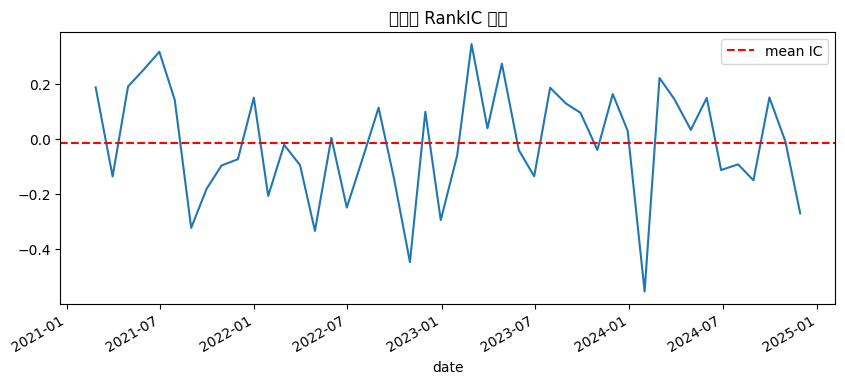

count    46.0000
mean     -0.0153
std       0.2024
min      -0.5526
25%      -0.1354
50%      -0.0142
75%       0.1485
max       0.3448
dtype: float64

In [19]:
# RankIC：衡量因子排序和未来收益排序的相关性
rank_ic = cleaned_factor.corrwith(future_ret_1m, axis=1, method="spearman")

fig, ax = plt.subplots(figsize=(10, 4))
rank_ic.plot(ax=ax)
ax.axhline(rank_ic.mean(), color="red", linestyle="--", label="mean IC")
ax.set_title("单因子 RankIC 序列")
ax.legend()
plt.show()

rank_ic.describe().round(4)


### 3.1 为什么只看 IC 还不够
因为一个因子即使平均 IC 还不错，也不代表分组收益一定有很明显的层次。

所以课堂上最好再补第二个视角：
- 把股票按因子值分组
- 看高分组和低分组未来收益差多少


In [20]:
# 做一个最简单的五分组：这里只看 Q5 - Q1
spread = []
for dt in cleaned_factor.index.intersection(future_ret_1m.index):
    fac = cleaned_factor.loc[dt].dropna()
    fut = future_ret_1m.loc[dt].dropna()
    sample = pd.concat([fac, fut], axis=1, join="inner")
    sample.columns = ["factor", "future_ret"]
    if len(sample) < 20:
        continue
    sample["bucket"] = pd.qcut(sample["factor"], 5, labels=False, duplicates="drop")
    q1 = sample.loc[sample["bucket"] == sample["bucket"].min(), "future_ret"].mean()
    q5 = sample.loc[sample["bucket"] == sample["bucket"].max(), "future_ret"].mean()
    spread.append([dt, q5 - q1])

spread = pd.DataFrame(spread, columns=["date", "q5_q1"]).set_index("date")
spread.head()


,q5_q1
date,
2021-02-26,0.042997
2021-03-31,-0.032695
2021-04-30,0.087202
2021-05-31,0.124275
2021-06-30,0.192655


## 4) 多因子：把多个特征一起用
单因子研究的意义，不是永远只用一个因子，而是先知道每个因子单独有没有信息。

真正进入策略时，更常见的做法是：
- 先把多个清洗后的因子放在一起
- 再用排序打分、线性回归等方式形成综合预测


### 3.2 旧讲义里还有一个很值得保留的步骤：先看分布
在正式算 IC 之前，先画一下某个截面的因子分布，会让学生更容易理解：
- 为什么要去极值
- 为什么要标准化
- 为什么有些月份的分布特别歪


d:\python_workspace\Quant\.venv\liangwen2\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 22240 (\N{CJK UNIFIED IDEOGRAPH-56E0}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\python_workspace\Quant\.venv\liangwen2\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 23376 (\N{CJK UNIFIED IDEOGRAPH-5B50}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\python_workspace\Quant\.venv\liangwen2\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 21407 (\N{CJK UNIFIED IDEOGRAPH-539F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\python_workspace\Quant\.venv\liangwen2\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 22987 (\N{CJK UNIFIED IDEOGRAPH-59CB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\python_workspace\Quant\.venv\liangwen2\Lib\site-packages\IPython\core\pylabtools.py:170: User

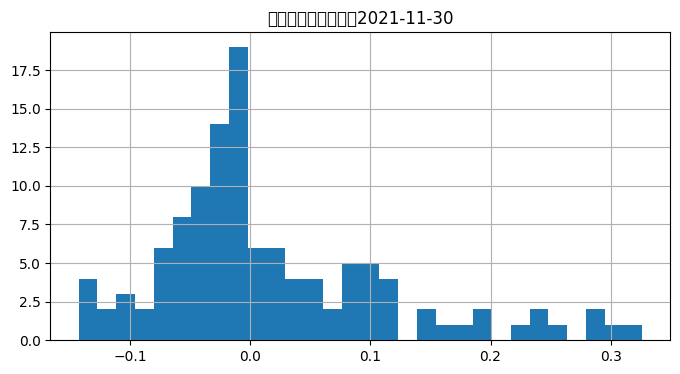

In [21]:
sample_date_hist = momentum_month.index[10]
sample_factor_hist = momentum_month.loc[sample_date_hist].dropna()

fig, ax = plt.subplots(figsize=(8, 4))
sample_factor_hist.hist(ax=ax, bins=30)
ax.set_title(f"因子原始分布示意：{sample_date_hist.date()}")
plt.show()


### 3.3 分组收益除了看 spread，还可以看累计曲线
旧讲义里分组分析的价值，不只是看单期 `Q5-Q1`，还可以继续累积。

这样学生会更容易把“截面统计”理解成“策略表现”。


d:\python_workspace\Quant\.venv\liangwen2\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 21333 (\N{CJK UNIFIED IDEOGRAPH-5355}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\python_workspace\Quant\.venv\liangwen2\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 22240 (\N{CJK UNIFIED IDEOGRAPH-56E0}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\python_workspace\Quant\.venv\liangwen2\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 23376 (\N{CJK UNIFIED IDEOGRAPH-5B50}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\python_workspace\Quant\.venv\liangwen2\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 32047 (\N{CJK UNIFIED IDEOGRAPH-7D2F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\python_workspace\Quant\.venv\liangwen2\Lib\site-packages\IPython\core\pylabtools.py:170: User

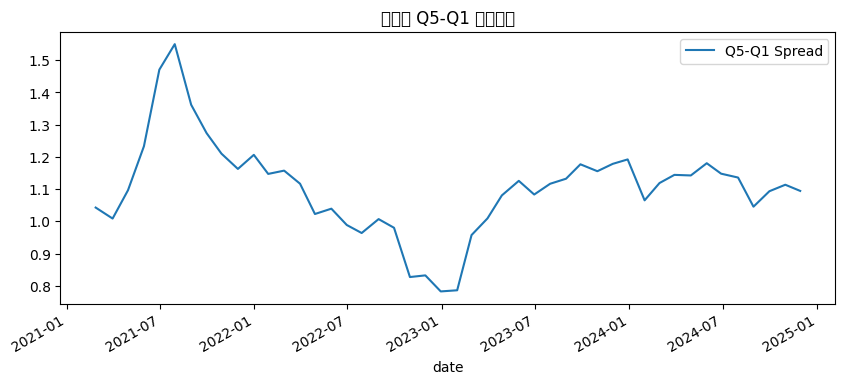

In [22]:
spread_nav = (1 + spread["q5_q1"].fillna(0)).cumprod()

fig, ax = plt.subplots(figsize=(10, 4))
spread_nav.plot(ax=ax, label="Q5-Q1 Spread")
ax.set_title("单因子 Q5-Q1 累计表现")
ax.legend()
plt.show()


### 4.1 为什么这里用线性回归而不是更复杂的模型
因为这门 workshop 的重点不是炫模型，而是把研究流程走通。

只要同学们能理解：
- 多个因子可以一起进入一个预测器
- 预测分数可以继续转成选股或持仓

这节课的核心目标就达到了。


In [23]:
# 把价值因子也做同样的清洗
value_clean = value_month.apply(lambda row: zscore(winsorize(-row.dropna())), axis=1)

panel_rows = []
valid_dates = cleaned_factor.index.intersection(value_clean.index).intersection(future_ret_1m.index)
for dt in valid_dates:
    tmp = pd.concat(
        [
            cleaned_factor.loc[dt].rename("mom"),
            value_clean.loc[dt].rename("value"),
            future_ret_1m.loc[dt].rename("future_ret"),
        ],
        axis=1,
        join="inner",
    ).dropna()
    tmp["date"] = dt
    tmp["order_book_id"] = tmp.index
    panel_rows.append(tmp.reset_index(drop=True))

panel = pd.concat(panel_rows, ignore_index=True)
panel.head()


,mom,value,future_ret,date,order_book_id
0,0.122519,0.893166,0.029467,2021-02-26,000001.XSHE
1,1.221603,0.790441,-0.093656,2021-02-26,000002.XSHE
2,-0.103590,0.578853,-0.076826,2021-02-26,000063.XSHE
3,-0.852017,0.563656,0.134872,2021-02-26,000100.XSHE
4,1.897659,0.671437,-0.116134,2021-02-26,000157.XSHE


In [24]:
# 用最简单的线性回归做滚动训练
from sklearn.linear_model import LinearRegression

preds = []
train_dates = sorted(panel["date"].unique())
last_model = None

for i in range(6, len(train_dates) - 1):
    train_window = train_dates[i - 6:i]
    test_date = train_dates[i]

    train = panel.loc[panel["date"].isin(train_window)]
    test = panel.loc[panel["date"] == test_date].copy()

    model = LinearRegression()
    model.fit(train[["mom", "value"]], train["future_ret"])
    test["pred"] = model.predict(test[["mom", "value"]])
    preds.append(test)
    last_model = model

preds = pd.concat(preds, ignore_index=True)
preds.head()


,mom,value,future_ret,date,order_book_id,pred
0,-0.113565,0.819412,0.007303,2021-08-31,000001.XSHE,0.000851
1,-0.073125,0.806131,0.076263,2021-08-31,000002.XSHE,0.001975
2,-0.927874,0.526458,-0.002108,2021-08-31,000063.XSHE,-0.007247
3,-0.337943,0.591504,-0.122020,2021-08-31,000100.XSHE,0.002434
4,-0.450533,0.772565,0.046954,2021-08-31,000157.XSHE,-0.004427


### 4.2 多因子回归在做什么
这一节很容易让学生以为“线性回归只是一个机器学习模型”。

但在这里，它更像一个因子整合器：
- 输入是多个已经清洗过的因子
- 输出是一个综合预测分数

所以重点不是模型复杂，而是“如何把多个因子合成一个信号”。


In [25]:
# 看一眼最近一次训练得到的系数，帮助学生理解“因子整合”到底是什么。
# 如果没有先运行上一格滚动训练，这里会用 panel 自动补一个演示模型。
from sklearn.linear_model import LinearRegression

if "last_model" not in globals() or last_model is None:
    demo_dates = sorted(panel["date"].unique())[:6]
    demo_train = panel.loc[panel["date"].isin(demo_dates)].copy()
    last_model = LinearRegression().fit(demo_train[["mom", "value"]], demo_train["future_ret"])

coef_demo = pd.Series(last_model.coef_, index=["mom", "value"])
coef_demo


mom     -0.000559
value   -0.001628
dtype: float64

## 5) 把多因子预测接到回测里
到这一步，逻辑就和第三节课重新接上了：
- 每个月给所有股票打分
- 选预测值最高的一组
- 等权持有到下个月


d:\python_workspace\Quant\.venv\liangwen2\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 22810 (\N{CJK UNIFIED IDEOGRAPH-591A}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\python_workspace\Quant\.venv\liangwen2\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 22240 (\N{CJK UNIFIED IDEOGRAPH-56E0}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\python_workspace\Quant\.venv\liangwen2\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 23376 (\N{CJK UNIFIED IDEOGRAPH-5B50}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\python_workspace\Quant\.venv\liangwen2\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 26376 (\N{CJK UNIFIED IDEOGRAPH-6708}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\python_workspace\Quant\.venv\liangwen2\Lib\site-packages\IPython\core\pylabtools.py:170: User

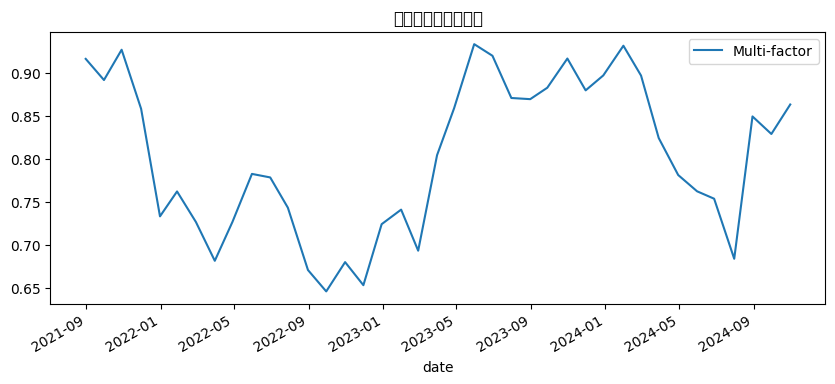

In [26]:
pred_pivot = preds.pivot(index="date", columns="order_book_id", values="pred")
future_pivot = preds.pivot(index="date", columns="order_book_id", values="future_ret")

mf_ret = []
for dt in pred_pivot.index:
    score = pred_pivot.loc[dt].dropna().sort_values(ascending=False)
    top10 = score.head(10).index.tolist()
    realized = future_pivot.loc[dt, top10].mean()
    mf_ret.append([dt, realized])

mf_ret = pd.DataFrame(mf_ret, columns=["date", "ret"]).set_index("date")
mf_nav = (1 + mf_ret["ret"].fillna(0)).cumprod()

fig, ax = plt.subplots(figsize=(10, 4))
mf_nav.plot(ax=ax, label="Multi-factor")
ax.set_title("多因子月度策略净值")
ax.legend()
plt.show()


### 5.1 怎么解读这条多因子净值曲线
这里不是要证明“线性回归一定赚钱”，而是要让学生看到：
- 因子研究并不是停留在 IC 层面
- 因子最终是可以被转成持仓规则并进入回测的


## 6) 课上小练习


### 练习 1：自己算一个简单的 zscore 因子
要求：
1. 取 `momentum_month` 某一个日期的横截面
2. 先 winsorize，再 zscore
3. 展示前 10 个股票的结果


In [27]:
# 练习 1：学生现场自己写


In [28]:
# 参考答案
sample_date = momentum_month.index[10]
ex1 = momentum_month.loc[sample_date].dropna()
ex1_clean = zscore(winsorize(ex1))
ex1_clean.head(10)


order_book_id
000001.XSHE   -0.599199
000002.XSHE    0.180471
000063.XSHE   -0.339145
000100.XSHE   -0.164037
000157.XSHE   -0.224795
000166.XSHE   -0.757192
000301.XSHE   -0.869034
000333.XSHE   -0.620645
000338.XSHE    0.293069
000408.XSHE   -0.221757
Name: 2021-11-30 00:00:00, dtype: float64

### 练习 2：自己看一个预测截面
要求：
1. 取一个 `pred_pivot` 日期
2. 排序后找出预测值最高的前 5 个股票
3. 看看这些股票是谁


In [29]:
# 练习 2：学生现场自己写


In [30]:
# 参考答案
sample_pred_date = pred_pivot.index[0]
top5_pred = pred_pivot.loc[sample_pred_date].dropna().sort_values(ascending=False).head(5)
top5_pred


order_book_id
000792.XSHE    0.220003
002466.XSHE    0.144082
002709.XSHE    0.124813
300661.XSHE    0.101753
002049.XSHE    0.100565
Name: 2021-08-31 00:00:00, dtype: float64

## 小结
这一节的关键词是：**因子评价与因子整合**。

本节真正想建立的是一条标准研究流程：
1. 先构造横截面因子
2. 做清洗和标准化
3. 用 RankIC / 分组收益判断它是否有信息
4. 再把多个因子整合成综合预测
5. 最后接入回测

本节常见易错点：
1. 只会构造因子，不会评价因子
2. 忽略极端值和标准化
3. 把单因子分析和多因子策略割裂开